# Układy równań liniowych
Główny cel laboratorium: porównanie jak liczy układ równań liniowych zadany macierzą źle i dobrze uwarunkowaną, jaki wpływ ma precyzja arytmetyczna (`float` vs `double`), a także jak duży zysk w postaci czasu działania programu można zyskać stosując dedykowany algorytm dla problemu macierz trójdiagonalnej, zamiast prostego algorytmu Gaussa.

## Część pierwsza: Macierz źle uwarunkowana
Mamy rozwiązać układ równań:
$$
    A \cdot X = b
$$
gdzie:
$$
    A = [a_{ij}]_{n \times n}, \quad i, j \in \{1, 2, \dots, n\} \\[4ex]
    
    \begin{cases}
        a_{ij} = 1, \quad &i = 1, j \in \{1, 2, \dots, n\} \\[2ex]
        a_{ij} = \frac{1}{i + j - 1}, \quad &i \in \{2, 3, \dots, n\}, j \in \{1, 2, \dots, n\}
    \end{cases} \\[4ex]

    X \ \text{to wektor o wymiarach} \ n \times 1 \text{, który stanowi permutację ze zbioru} \ \{-1, 1\}
$$
natomiast $b$ wyliczamy na podstawie $A$ oraz $X$.

Naszym zadaniem jest, dla pojedynczej i podwójnej precyzji, znaleźć z poniższą normą (mój wybór padł na błąd bezwzględny):
$$
    \|X\|_{\max} = \max_{i \in 1, \dots, n} (|x_i - \overline{x_i}|), \quad \text{gdzie} \ x_i \ \text{to wartość referencyjna, natomiast} \ \overline{x_i} \ \text{to wartość wyliczona}
$$

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Type, List, Dict, Any
from pathlib import Path

SEED = 11052026

In [49]:
def generate_first_matrix(n: int, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Generates an n x n matrix based on a specific index-based formula.
    
    The formula is defined as:
    - a_1j = 1
    - a_ij = 1 / (i + j - 1) for i != 1
    where i, j are 1-based indices.

    Parameters:
    -------
        n (int): The size of the square matrix.
        precision (Type[np.number]): The NumPy floating-point dtype (e.g., np.float32, np.float64).

    Returns:
    -------
        np.ndarray: Calculated matrix of shape (n, n) with the specified precision.
        
    Raises:
    -------
    ValueError
        If matrix dimension n is not a positive integer.
    """
    
    if not isinstance(n, int) or n <= 0:
        raise ValueError("Matrix dimension n must be a positive integer")
    
    i = np.arange(1, n + 1, dtype=precision).reshape(-1, 1)
    j = np.arange(1, n + 1, dtype=precision).reshape(1, -1)
    
    matrix = 1.0 / (i + j - 1.0)
    
    matrix[0, :] = 1.0
    
    return matrix


### Reużywalny kod dla $X$ oraz $b$
O ile kod dla wyliczania $A$ jest specyficzny dla przykładu, tak kod znajdujący się poniżej, służący generowaniu losowej permutacji $-1$ oraz $1$ dla wektora $X$, a także wyliczania wektora $b$ będzie stanowił podstawę dla obliczeń późniejszych punktów.

In [50]:
def generate_x_vector(n: int, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Generates a vector X of size n, which is a random permutation of values -1 and 1.
    
    Parameters:
    -------
        n (int): The size of the vector.
        precision (Type[np.number]): The NumPy floating-point dtype.

    Returns:
    -------
        np.ndarray: Vector of shape (n,) containing random -1.0 or 1.0 values.
    """
    
    rng = np.random.default_rng(SEED)
    x = rng.choice([-1.0, 1.0], size=n).astype(precision)
    return x

In [51]:
def calculate_b_vector(A: np.ndarray, x: np.ndarray) -> np.ndarray:
    """
    Calculates the constant terms vector b = A * x.
    
    Parameters:
    -------
        A (np.ndarray): The coefficient matrix.
        x (np.ndarray): The solution vector.

    Returns:
    -------
        np.ndarray: The resulting vector b.
    """

    return A @ x

## Algorytm eliminacji Gaussa
Algorytm eliminacji Gaussa rozwiązujący układ równań liniowych $A \cdot X = b$. Wykorzystuje częściowy wybór elementu podstawowego (*partial pivoting*).

In [52]:
import numpy as np

def gaussian_elimination(A: np.ndarray, b: np.ndarray, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Solves a system of linear equations Ax = b using Gaussian elimination 
    with partial pivoting.

    Parameters:
    ----------
    A : np.ndarray
        Coefficient matrix of shape (n, n). 
        Should be a 2D numerical array.
    b : np.ndarray
        Constant terms vector of shape (n,) or (n, 1).

    Returns:
    -------
    np.ndarray
        Solution vector x of shape (n,).

    Raises:
    -------
    ValueError
        If matrix A is not square, the dimensions of A and b do not match,
        or if the matrix is singular (no unique solution).
    """
    # 1. Dimension validation
    n = A.shape[0]
    if A.shape[1] != n:
        raise ValueError("Matrix A must be a square matrix.")
    if b.shape[0] != n:
        raise ValueError("Dimensions of matrix A and vector b do not match.")

    # 2. Initialize floating-point copies
    # We work on copies to avoid modifying the original data 
    # provided by the user and to prevent integer division issues.
    A_aug = np.array(A, dtype=precision)
    b_aug = np.array(b, dtype=precision).flatten()
    
    # 3. Forward Elimination phase
    for i in range(n):
        # Partial pivoting: find the largest element in the current column below the diagonal
        max_row_index = np.argmax(np.abs(A_aug[i:n, i])) + i
        
        # Protection against singular matrix
        if A_aug[max_row_index, i] == 0.0:
            raise ValueError(f"Encountered exact zero pivot at column {i}. Matrix is singular.")
            
        # If the largest element is not on the diagonal, swap rows
        if max_row_index != i:
            A_aug[[i, max_row_index]] = A_aug[[max_row_index, i]]
            b_aug[[i, max_row_index]] = b_aug[[max_row_index, i]]
            
        # Actual Gaussian elimination (zeroing elements below the diagonal)
        for j in range(i + 1, n):
            # Calculate the multiplier
            multiplier = A_aug[j, i] / A_aug[i, i]
            # Subtract the multiplied i-th row from the j-th row.
            # Using numpy vectorized operations for performance: A_aug[j, i:]
            A_aug[j, i:] -= multiplier * A_aug[i, i:]
            b_aug[j] -= multiplier * b_aug[i]

    # 4. Back Substitution phase
    x = np.zeros(n, dtype=precision)
    for i in range(n - 1, -1, -1):
        # Sum the products of already calculated 'x' and coefficients from the current row
        dot_product = np.sum(A_aug[i, i+1:] * x[i+1:])
        x[i] = (b_aug[i] - dot_product) / A_aug[i, i]
        
    return x

### Norma (błąd bezwzględny)
Jako normę przyjąłem maksymalny błąd bezwzględny po elementach wektorów. Tak, jak to zostało opisane w nagłówku:
$$
    \|X\|_{\max} = \max_{i \in 1, \dots, n} (|x_i - \overline{x_i}|), \quad \text{gdzie} \ x_i \ \text{to wartość referencyjna, natomiast} \ \overline{x_i} \ \text{to wartość wyliczona}
$$

In [53]:
def max_absolute_error(x_ref: np.ndarray, x_calc: np.ndarray) -> float:
    """
    Calculates the maximum absolute error (infinity norm of the error vector) 
    between the reference solution and the calculated solution.

    Parameters:
    ----------
    x_ref : np.ndarray
        The reference (exact) solution vector.
    x_calc : np.ndarray
        The calculated (approximate) solution vector.

    Returns:
    -------
    float
        The maximum absolute difference between corresponding elements.
        
    Raises:
    -------
    ValueError
        If the shapes of x_ref and x_calc do not match.
    """
    if x_ref.shape != x_calc.shape:
        raise ValueError("Dimensions of reference and calculated vectors must match.")
        
    return float(np.max(np.abs(x_ref - x_calc)))

## Eksperyment numeryczny: zadanie 1
Mamy już wszystkie funkcje potrzebne do wykonania zadania pierwszego. Interesuje nas wartość normy maksimum w zależności od precyzji, oraz rozmiaru macierzy. Poniższy kod zrzuca te dane do jednego pliku CSV, na podstawie którego zostanie sporządzone sprawozdanie.

In [54]:
def generate_experiment_data(filename: str = "exercise1_data.csv") -> pd.DataFrame:
    """
    Runs the Gaussian elimination experiment for matrix sizes n from 2 to 20,
    calculating the max absolute error and execution time for both float32 and float64.
    Saves the results to a CSV file.

    Parameters:
    ----------
    filename : str
        The name of the output CSV file.

    Returns:
    -------
    pd.DataFrame
        A DataFrame containing the aggregated results of the experiment.
    """
    
    # Create a designated data/ folder for CSV files
    filepath = Path("data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    # We will store the results as a list of dictionaries, 
    # which is very efficient for building pandas DataFrames.
    results: List[Dict[str, Any]] = []
    
    # Loop over matrix sizes from 2 to 20
    for n in range(2, 21):
        row_data = {"n": n}
        
        # Test both precisions
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            
            # 1. Generate inputs
            A = generate_first_matrix(n, precision)
            x_ref = generate_x_vector(n, precision)
            b = calculate_b_vector(A, x_ref)
            x_calc = gaussian_elimination(A, b, precision)
            
            # 2. Calculate max absolute error
            error = max_absolute_error(x_ref, x_calc)
            
            # 4. Save results to the current row
            row_data[f"||x||_max_{precision_name}"] = error
            
        results.append(row_data)
        
    # Create a DataFrame from the collected data
    df = pd.DataFrame(results)
    
    # Format the scientific notation to match the table aesthetics (e.g., 2.3842e-07)
    for col in df.columns:
        if col != "n":
            df[col] = df[col].apply(lambda val: f"{val:.4e}")
    
    # Save the DataFrame to a CSV file without the index column
    df.to_csv(filepath, index=False)
    print(f"Experiment completed. Data successfully saved to '{filename}'.")
    
    return df

results_df = generate_experiment_data()
display(results_df.head())

Experiment completed. Data successfully saved to 'exercise1_data.csv'.


,n,||x||_max_float32,||x||_max_float64
0,2,2.3842e-07,2.2204e-16
1,3,5.2452e-06,2.6978e-14
2,4,2.5749e-04,1.7986e-13
3,5,4.0412e-03,5.9348e-12
4,6,4.9290e-02,1.4487e-10


### Wykres normy maksimum w zależności od rozmiaru macierzy

Saved plot to: plots\exercise1_max_norm_n.png


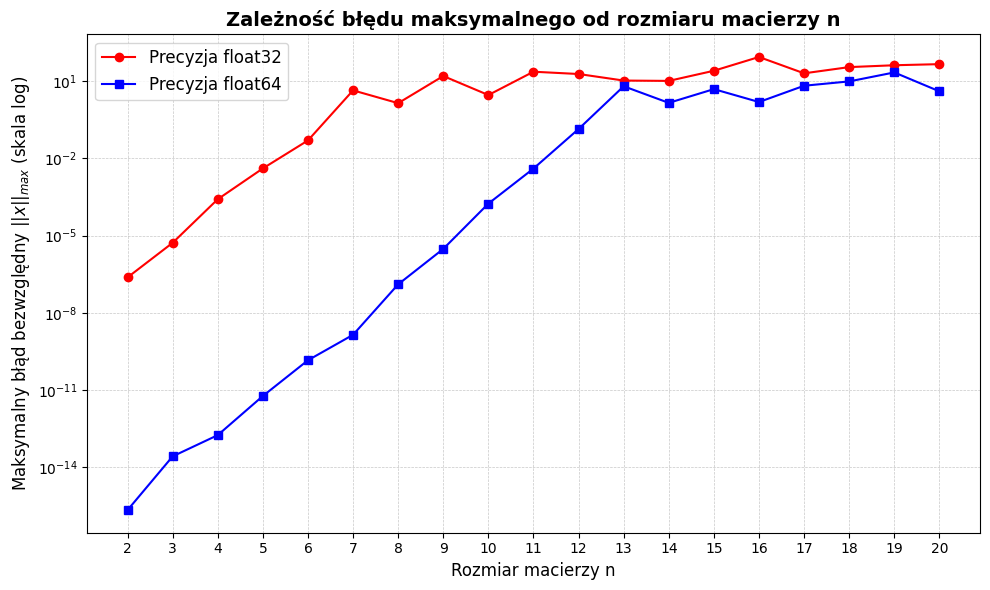

In [56]:
def plot_error_vs_n(csv_filename: str) -> None:
    """
    Reads experimental results from a CSV file and plots the maximum absolute error
    (||x||_max) as a function of matrix size (n) for both float32 and float64 precisions.
    
    Parameters:
    ----------
    csv_filename : str
        The name of the CSV file containing the experiment data.
        
    Raises:
    ----------
    FileNotFoundError
        If a file with name csv_filename doesn't exist
    """
    # 0. Create a path to the csv_filename
    path = Path("data") / csv_filename
    if not path.exists():
        raise FileNotFoundError(f"Couldn't locate file {path}")
    
    # 1. Load data
    df = pd.read_csv(path)
    
    # 2. Setup the plot
    plt.figure(figsize=(10, 6))
    
    # 3. Plot both series using semi-logarithmic scale (logarithmic Y-axis)
    # We use different markers ('o' and 's') and colors to easily distinguish the lines
    plt.semilogy(df["n"], df["||x||_max_float32"], marker='o', linestyle='-', color='red', label='Precyzja float32')
    plt.semilogy(df["n"], df["||x||_max_float64"], marker='s', linestyle='-', color='blue', label='Precyzja float64')
    
    # 4. Styling and labels
    plt.title('Zależność błędu maksymalnego od rozmiaru macierzy n', fontsize=14, fontweight='bold')
    plt.xlabel('Rozmiar macierzy n', fontsize=12)
    plt.ylabel('Maksymalny błąd bezwzględny $||x||_{max}$ (skala log)', fontsize=12)
    
    # Set x-ticks to be exactly the integer sizes of the matrices
    plt.xticks(df["n"])
    
    # Add a grid for both major and minor ticks (helpful on log scales)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    
    # Add legend
    plt.legend(fontsize=12)
    
    # Adjust layout to not cut off labels
    plt.tight_layout()
    
    # 5. Save the plot
    filename = "exercise1_max_norm_n.png"
    save_path = Path("plots") / filename
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Saved plot to: {save_path}")
    
    # Display the plot in the notebook as well
    plt.show()

plot_error_vs_n("exercise1_data.csv")